# **Install Roboflow**


In [ ]:
!pip install roboflow

# **Download Dataset from Roboflow**

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="tXr10qCHwVjmdrbIAB2m")
project = rf.workspace("food-data-eqvzt").project("food-zety1")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...


# **Rename Dataset Folder**

In [ ]:
import os

old_name = 'Food-1'
new_name = 'Food_Classification_Datasets'

if os.path.exists(old_name) and not os.path.exists(new_name):
    os.rename(old_name, new_name)
    print("Folder renamed successfully.")
else:
    print("Rename skipped (source not found or already renamed).")


Rename skipped (source not found or already renamed).


# **Import Libraries**

In [ ]:
import pandas as pd
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image


# Set device to GPU ("cuda") if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


# **Define Directries**

In [ ]:
train_dir = 'Food_Classification_Datasets/train'

# **Create the datasets class**

In [ ]:
# Define a custom dataset class inheriting from PyTorch Dataset
class ImageFolderDataset(Dataset):

    # Constructor method to initialize dataset
    def __init__(self, root_dir, transforms=None):
        # Store the root directory where dataset is located
        self.root_dir = root_dir

        # Store optional transformations (like resize, normalize, etc.)
        self.transforms = transforms

        # Get all folder names (each folder = one class) and sort them
        self.classes = sorted(os.listdir(root_dir))

        # Create a dictionary mapping class name to numeric label (index)
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        # Suppose self.classes = ['burger', 'pizza', 'sushi']
        # enumerate(self.classes) gives:
        # (0, 'burger'), (1, 'pizza'), (2, 'sushi')

        # Initialize empty list to store (image_path, label) pairs
        self.samples = []

        # Loop through each class (folder)
        for cls in self.classes:

            # Create full path to the class folder
            cls_folder = os.path.join(root_dir, cls)

            # Skip if it's not a directory (safety check)
            if not os.path.isdir(cls_folder):
                continue

            # Loop through all images inside the class folder
            for img_name in os.listdir(cls_folder):

                # Create full path to the image file
                img_path = os.path.join(cls_folder, img_name)

                # Append tuple of (image path, corresponding label index)
                self.samples.append((img_path, self.class_to_idx[cls]))

    # Return total number of samples in dataset
    def __len__(self):
        return len(self.samples)

    # Get a single sample (image and label) by index
    def __getitem__(self, idx):

        # Retrieve image path and label from samples list
        img_path, label = self.samples[idx]

        # Open the image using PIL
        img = Image.open(img_path)

        # Apply transformations if provided
        if self.transforms:
            img = self.transforms(img)

        # Return processed image and its label
        return img, label

# **Plot bar graph**

{'fried_rice': 252, 'pakode': 177, 'paani_puri': 86, 'chole_bhature': 269, 'burger': 190, 'samosa': 157, 'pav_bhaji': 208, 'butter_naan': 219, 'pizza': 165, 'kulfi': 156, 'jalebi': 189, 'idli': 203, 'kadai_paneer': 262, 'momos': 202, 'kaathi_rolls': 176, 'dal_makhani': 222, 'masala_dosa': 202, 'chapati': 258, 'chai': 247, 'dhokla': 180}


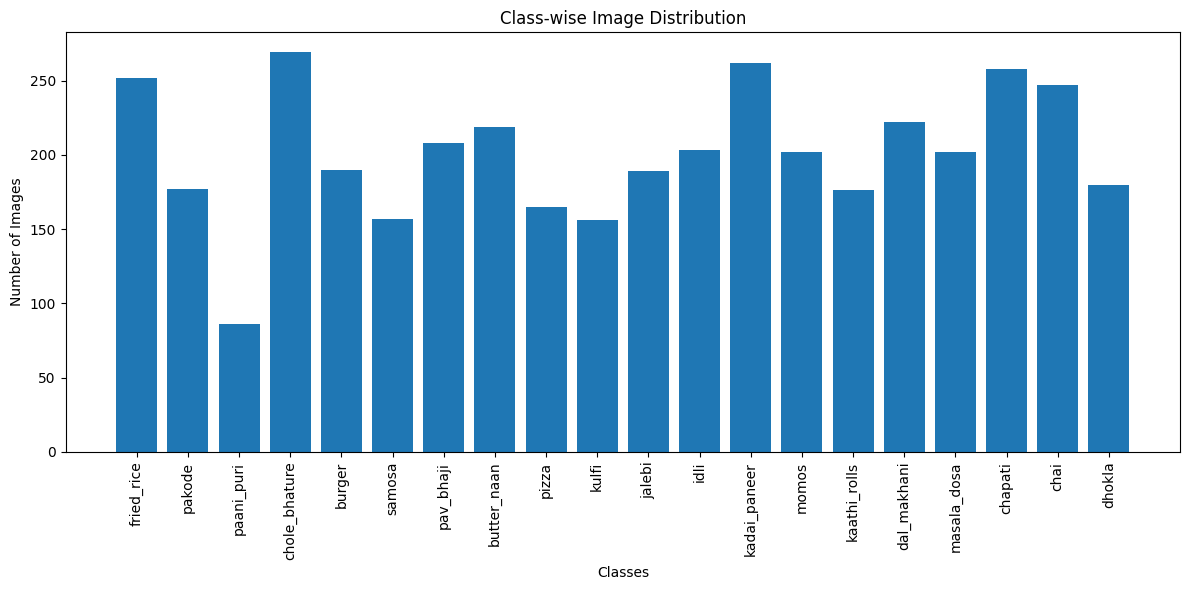

In [ ]:
import os
import matplotlib.pyplot as plt

count_dict = {}

# Loop over all items (class folders) inside the training directory
for fld in os.listdir(train_dir):

    # Create full path to the current folder
    fld_path = os.path.join(train_dir, fld)

    # Check if the current item is actually a directory (class folder)
    if os.path.isdir(fld_path):

        # Count number of files (images) inside this class folder
        img_count = len(os.listdir(fld_path))

        # Store the count in dictionary with class name as key
        count_dict[fld] = img_count

print(count_dict)

# -------- BAR GRAPH --------
classes = list(count_dict.keys())
counts = list(count_dict.values())

plt.figure(figsize=(12, 6))
plt.bar(classes, counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class-wise Image Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



# **Create the datsets**

In [ ]:
# Import DataLoader to load data in batches for training
from torch.utils.data import DataLoader

# Define a sequence of image transformations
transformation = transforms.Compose([

    # Resize all images to 60x60 pixels
    transforms.Resize((60, 60)),

    # Convert image to PyTorch tensor (scales pixel values to [0,1])
    transforms.ToTensor(),

    # Normalize image using ImageNet mean and standard deviation
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # Mean for RGB channels
        std=[0.229, 0.224, 0.225]    # Standard deviation for RGB channels
    )
])

# Create training dataset using custom ImageFolderDataset class
train_dataset = ImageFolderDataset(

    # Path to training data directory
    root_dir=train_dir,

    # Apply defined transformations to each image
    transforms=transformation
)

# Create DataLoader to load dataset in batches
train_loader = DataLoader(

    # Dataset to load data from
    train_dataset,

    # Number of samples per batch
    batch_size=32,

    # Shuffle data at every epoch for better training
    shuffle=True,

    # Number of worker threads for loading data (parallel loading)
    num_workers=2,

    # Speed optimization: faster transfer of data to GPU (if using CUDA)
    pin_memory=True
)


# **Get the length**

In [ ]:
print(train_dataset.__getitem__(0)[0].shape)
print(len(train_loader))
print(len(os.listdir(train_dir)))

torch.Size([3, 60, 60])
126
20


#**Get class_names**

In [ ]:
class_names = train_dataset.classes
print(class_names)

['burger', 'butter_naan', 'chai', 'chapati', 'chole_bhature', 'dal_makhani', 'dhokla', 'fried_rice', 'idli', 'jalebi', 'kaathi_rolls', 'kadai_paneer', 'kulfi', 'masala_dosa', 'momos', 'paani_puri', 'pakode', 'pav_bhaji', 'pizza', 'samosa']


# **Plot the images**

['burger', 'butter_naan', 'chai', 'chapati', 'chole_bhature', 'dal_makhani', 'dhokla', 'fried_rice', 'idli', 'jalebi', 'kaathi_rolls', 'kadai_paneer', 'kulfi', 'masala_dosa', 'momos', 'paani_puri', 'pakode', 'pav_bhaji', 'pizza', 'samosa']


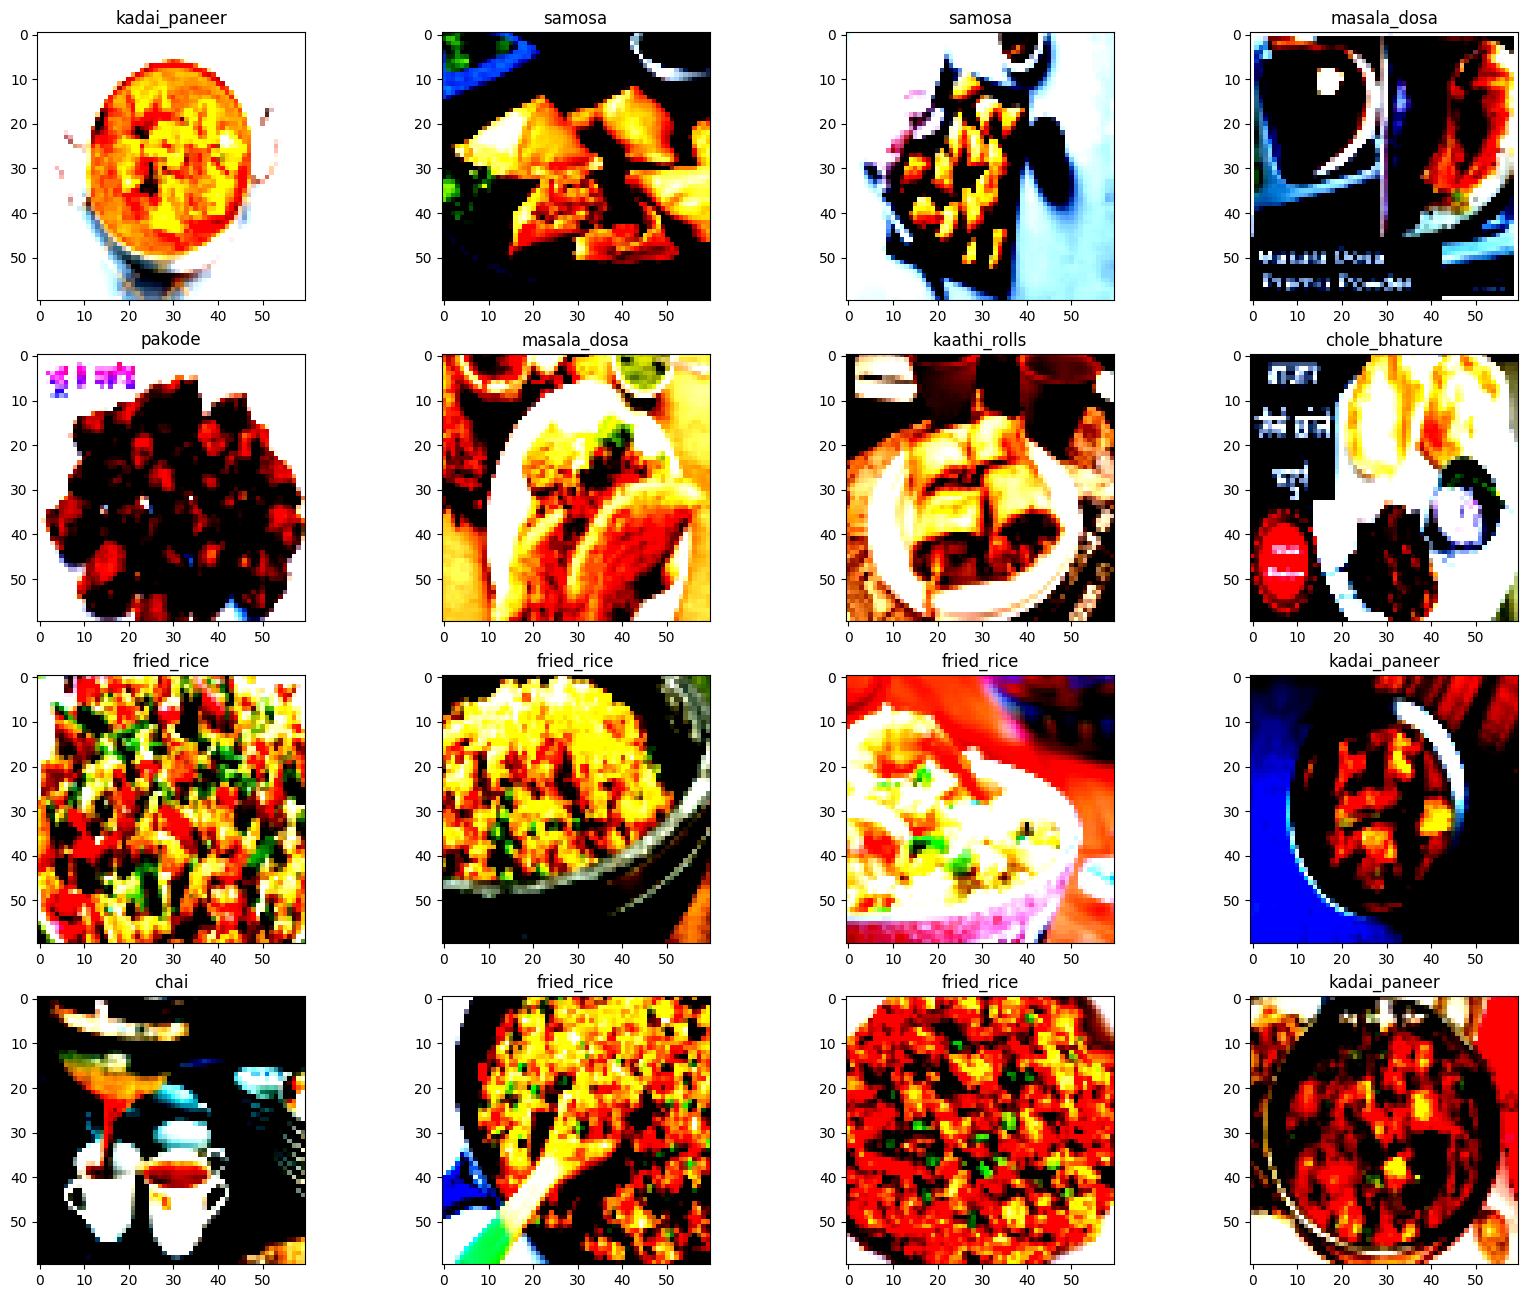

In [ ]:
samples,labels = next(iter(train_loader))

fig, axes = plt.subplots(4,4,figsize=(20,16))
axes = axes.ravel()

class_names = train_dataset.classes
print(class_names)

for i in range(16):
    label = class_names[labels[i].item()]
    axes[i].imshow(samples[i].permute(1,2,0))  ## (C,H,W) to (H,W,C)
    axes[i].set_title(label)

# **Create the CNN model**

In [ ]:
# Import neural network module from PyTorch
import torch.nn as nn

# Import functional API (for activation functions like ReLU)
import torch.nn.functional as F

# Define a custom Convolutional Neural Network class
class CNN(nn.Module):

    # Constructor to initialize layers
    def __init__(self, num_classes=20):

        # Call parent class constructor
        super(CNN, self).__init__()

        # -------------------------------------------------
        # Input image shape: 3 (RGB channels) × 60 × 60
        # -------------------------------------------------

        # -------- Convolution Block 1 --------

        # First convolution layer:
        # Input channels = 3 (RGB), Output channels = 16, Kernel size = 3x3
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3
        )

        # Max pooling layer with 2x2 window (reduces spatial size by half)
        self.pool1 = nn.MaxPool2d(kernel_size=2)


        # -------- Convolution Block 2 --------

        # Second convolution layer:
        # Input channels = 16, Output channels = 32
        self.conv2 = nn.Conv2d(16, 32, 3)

        # Max pooling layer
        self.pool2 = nn.MaxPool2d(2)


        # -------- Convolution Block 3 --------

        # Third convolution layer:
        # Input channels = 32, Output channels = 64
        self.conv3 = nn.Conv2d(32, 64, 3)

        # Max pooling layer
        self.pool3 = nn.MaxPool2d(2)


        # -------- Fully Connected Layers --------

        # Flatten layer to convert 3D feature maps into 1D vector
        self.flatten = nn.Flatten()

        # First fully connected (dense) layer
        # Input features = 64 * 5 * 5 = 1600, Output = 256
        self.fc1 = nn.Linear(64 * 5 * 5, 256)

        # Second fully connected layer
        # Input = 256, Output = 128
        self.fc2 = nn.Linear(256, 128)

        # Final output layer
        # Input = 128, Output = number of classes (e.g., 20)
        # Produces raw scores (logits), no softmax applied
        self.fc3 = nn.Linear(128, num_classes)


    # Forward pass: defines how data flows through the network
    def forward(self, x):

        # -------- Block 1 --------

        # Apply first convolution
        x = self.conv1(x)

        # Apply ReLU activation function
        x = F.relu(x)

        # Apply max pooling
        x = self.pool1(x)


        # -------- Block 2 --------

        # Apply second convolution
        x = self.conv2(x)

        # Apply ReLU activation
        x = F.relu(x)

        # Apply max pooling
        x = self.pool2(x)


        # -------- Block 3 --------

        # Apply third convolution
        x = self.conv3(x)

        # Apply ReLU activation
        x = F.relu(x)

        # Apply max pooling
        x = self.pool3(x)


        # -------- Flatten --------

        # Convert feature maps into a 1D vector
        x = self.flatten(x)


        # -------- Fully Connected Layers --------

        # First dense layer
        x = self.fc1(x)

        # ReLU activation
        x = F.relu(x)

        # Second dense layer
        x = self.fc2(x)

        # ReLU activation
        x = F.relu(x)

        # Final output layer (logits)
        x = self.fc3(x)

        # Return final predictions
        return x


# Create model instance and move it to selected device (CPU or GPU)
model = CNN().to(device)

# **Get the model summary**

In [ ]:
from torchsummary import summary
summary(model, (3,60,60)) # (C,H,W)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 58, 58]             448
         MaxPool2d-2           [-1, 16, 29, 29]               0
            Conv2d-3           [-1, 32, 27, 27]           4,640
         MaxPool2d-4           [-1, 32, 13, 13]               0
            Conv2d-5           [-1, 64, 11, 11]          18,496
         MaxPool2d-6             [-1, 64, 5, 5]               0
           Flatten-7                 [-1, 1600]               0
            Linear-8                  [-1, 256]         409,856
            Linear-9                  [-1, 128]          32,896
           Linear-10                   [-1, 20]           2,580
Total params: 468,916
Trainable params: 468,916
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.04
Forward/backward pass size (MB): 0.82
Params size (MB): 1.79
Estimated T

# **Define optimizers**

In [ ]:
# Define the loss function (Cross Entropy Loss for multi-class classification)
# Moves the loss function to the selected device (CPU/GPU)
criterion = nn.CrossEntropyLoss().to(device)

# Define the optimizer (Adam) to update model weights
# model.parameters() → all learnable parameters of the model
# lr=0.0006 → learning rate (controls how fast the model learns)
optimizer = optim.Adam(model.parameters(), lr=0.0006)

# Number of times the entire dataset will be passed through the model during training
epochs = 50

# **Define model training**

In [ ]:
# Import tqdm for progress bar visualization during training
from tqdm import tqdm

# List to store training loss for each epoch
train_loss = []

# List to store training accuracy for each epoch
train_accuracy = []

# Loop over all epochs
for epoch in range(epochs):

    # Set model to training mode (enables dropout, batchnorm updates, etc.)
    model.train()

    # Initialize number of correct predictions
    correct = 0

    # Initialize running loss (accumulates total loss)
    running_loss = 0.0

    # Total number of samples processed
    total_samples = 0

    # Create a progress bar for the training loop
    progress_bar = tqdm(
        train_loader,                          # DataLoader providing batches
        desc=f"Epoch [{epoch+1}/{epochs}]",    # Description shown on progress bar
        leave=True                             # Keep progress bar after completion
    )

    # Loop over batches of data
    for data, labels in progress_bar:

        # Move input data to device (GPU/CPU)
        # non_blocking=True speeds up transfer when using pinned memory
        data = data.to(device, non_blocking=True)

        # Move labels to device
        labels = labels.to(device, non_blocking=True)

        # Reset gradients from previous iteration
        optimizer.zero_grad()

        # -------- Forward Pass --------
        # Pass input through model to get raw logits (no softmax)
        outputs = model(data)

        # Compute loss between predicted logits and true labels
        # CrossEntropyLoss internally applies softmax
        loss = criterian(outputs, labels)

        # -------- Backpropagation --------
        # Compute gradients
        loss.backward()

        # Update model weights using optimizer
        optimizer.step()

        # -------- Statistics --------

        # Accumulate total loss (multiply by batch size for correct averaging later)
        running_loss += loss.item() * data.size(0)

        # Get predicted class (index with highest logit value)
        preds = outputs.argmax(dim=1)

        # Count correct predictions in this batch
        correct += (preds == labels).sum().item()

        # Update total number of samples processed
        total_samples += labels.size(0)

    # Compute average loss for the epoch
    epoch_loss = running_loss / total_samples

    # Compute accuracy for the epoch (in percentage)
    epoch_acc = 100 * correct / total_samples

    # Store loss for plotting later
    train_loss.append(epoch_loss)

    # Store accuracy for plotting later
    train_accuracy.append(epoch_acc)

    # Print training results for the epoch
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Training Loss: {epoch_loss:.4f} "
        f"Training Accuracy: {epoch_acc:.2f}%"
    )

Epoch [1/50]: 100%|██████████| 126/126 [00:21<00:00,  5.87it/s]


Epoch [1/50] Training Loss: 2.8322 Training Accuracy: 10.72%


Epoch [2/50]: 100%|██████████| 126/126 [00:14<00:00,  8.55it/s]


Epoch [2/50] Training Loss: 2.6030 Training Accuracy: 17.66%


Epoch [3/50]: 100%|██████████| 126/126 [00:15<00:00,  8.36it/s]


...

Epoch [48/50] Training Loss: 0.0002 Training Accuracy: 100.00%


Epoch [49/50]: 100%|██████████| 126/126 [00:14<00:00,  8.43it/s]


Epoch [49/50] Training Loss: 0.0002 Training Accuracy: 100.00%


Epoch [50/50]: 100%|██████████| 126/126 [00:15<00:00,  8.24it/s]

Epoch [50/50] Training Loss: 0.0002 Training Accuracy: 100.00%


# **Plot the graph**

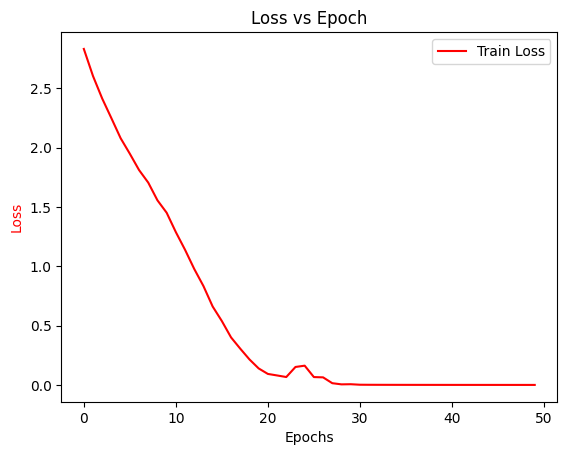

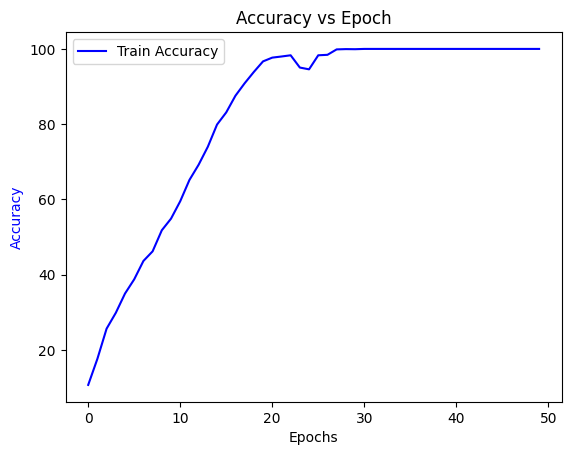

In [ ]:
epoch_log = [*range(epochs)]

fig,ax1 = plt.subplots()
ax1.plot(epoch_log,train_loss,'r-',label = 'Train Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss',color='r')
ax1.set_title('Loss vs Epoch')
ax1.legend()
plt.show()

fig,ax2 = plt.subplots()
ax2.plot(epoch_log,train_accuracy,'b-',label = 'Train Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy',color='b')
ax2.set_title('Accuracy vs Epoch')
ax2.legend()
plt.show()

# **Save the model**

In [ ]:
path = 'food.pth'
torch.save(model.state_dict(), path)

In [ ]:
from google.colab import files
files.download(path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Load the model**

In [ ]:
model.load_state_dict(torch.load(path, map_location=device))
model.to(device)
model.eval()   # or model.train()


CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1600, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=20, bias=True)
)

# **Plot the images**

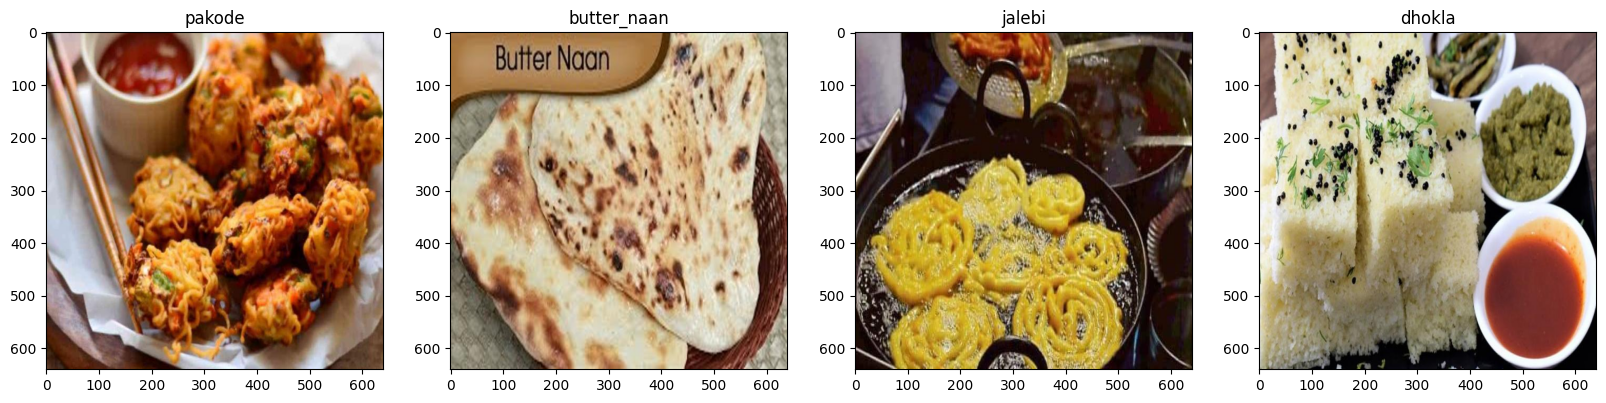

In [ ]:
import random

test_dir = 'Food_Classification_Datasets/test'
test_flds = os.listdir(test_dir)


# Define a preprocessing function for a single input image
def preprocessing(image):

    # Apply the same transformations used during training
    # Output shape: (C, H, W) → (3, 60, 60)
    img = transformation(image)

    # Add batch dimension since model expects input as (B, C, H, W)
    # (3, 60, 60) → (1, 3, 60, 60)
    img = img.unsqueeze(0)

    # Return preprocessed image ready for model inference
    return img


fig, axes = plt.subplots(1,4,figsize=(20,16))
axes = axes.ravel()

class_names = train_dataset.classes


# Loop 4 times to display 4 random test images with predictions
for i in range(0, 4):

    # Randomly select a class folder from test folders
    fld = random.choice(test_flds)

    # Create full path to the selected class folder
    fld_path = os.path.join(test_dir, fld)

    # Get list of all images inside that folder
    img_list = os.listdir(fld_path)

    # Randomly select one image and create full image path
    img_path = os.path.join(test_dir, fld, random.choice(img_list))

    # Open the image using PIL
    image = Image.open(img_path)

    # Preprocess the image (resize, normalize, add batch dimension)
    preprocessed_img = preprocessing(image)

    # Pass image through model (move to device first)
    output = model(preprocessed_img.to(device))

    # Get predicted class index (highest score/logit)
    pred = torch.argmax(output).item()

    # Convert predicted index to class name
    label = class_names[pred]

    # Display the image in subplot
    axes[i].imshow(image)

    # Set predicted label as title of the image
    axes[i].set_title(label)

# Show all plotted images
plt.show()
